# Exercise Recognition Pipeline v5

## v4 → v5 변경

### Sliding window 학습 (핵심 변경)

v4: 영상 1개당 random crop 1개 → 추론과 분포 불일치
v5: 영상마다 stride=48로 모든 96-프레임 윈도우를 enumerate → **추론과 동일한 분포로 학습**

### Dataset 구조

```
v4: dataset[i] → 영상 i 한 곳에서 random crop
v5: dataset[i] → (영상_idx, 윈도우_시작_위치) 미리 정해진 윈도우
```

학습 샘플 수: 156 영상 → 약 1,500~2,500 윈도우

### 그 외는 v4와 동일
- Multi-task ST-GCN (shared backbone + action / phase head)
- Phase 3-class (ready / down / up)
- 96-frame clip, sliding window 추론
- State machine 카운팅


## 2. Import

In [1]:

import os, json, math, random
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE, '| torch:', torch.__version__, '| numpy:', np.__version__)

device: cuda | torch: 2.11.0+cu128 | numpy: 2.4.4


## 3. 경로 + 상수

In [2]:
ROOT      = Path('../data/측면/data')
VIDEO_DIR = ROOT
LABEL_DIR = ROOT / 'labels'
WORK_DIR  = ROOT / 'workdir'
POSE_DIR  = WORK_DIR / 'poses'
CKPT_DIR  = WORK_DIR / 'checkpoints'
PLOT_DIR  = WORK_DIR / 'plots'

for d in [WORK_DIR, POSE_DIR, CKPT_DIR, PLOT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

CLASS_LIST  = ['squat', 'benchpress', 'deadlift']
CLASS_TO_ID = {c: i for i, c in enumerate(CLASS_LIST)}
ID_TO_CLASS = {i: c for c, i in CLASS_TO_ID.items()}
NUM_CLASSES = 3

PHASE_READY = 0
PHASE_DOWN  = 1
PHASE_UP    = 2
NUM_PHASES  = 3
PHASE_NAMES = ['ready', 'down', 'up']

# v5 학습 설정
CLIP_LEN = 32
STRIDE   = 4              # train sliding window stride (50% overlap)
MAX_WINDOWS_PER_VIDEO = 20 # 긴 영상 윈도우 수 제한 (deadlift 비대칭 완화)

print('=== 캐시 상태 ===')
print(f"  pose 캐시       : {len(list(POSE_DIR.rglob('*.npz')))}개")
print(f"  meta_v4.csv     : {'있음' if (WORK_DIR/'meta_v4.csv').exists() else '없음'}")
print(f"  multitask_v5.pt : {'있음' if (CKPT_DIR/'multitask_v5_best.pt').exists() else '없음'}")

=== 캐시 상태 ===
  pose 캐시       : 208개
  meta_v4.csv     : 있음
  multitask_v5.pt : 있음


## 4. 라벨 파싱 (v4와 동일)

In [3]:
csv_list = sorted(LABEL_DIR.glob('*.csv'))
assert len(csv_list) > 0, f'라벨 CSV 없음: {LABEL_DIR}'
LABEL_CSV = csv_list[0]
print('라벨 파일:', LABEL_CSV)

df = pd.read_csv(LABEL_CSV)
df.columns = [str(c).strip() for c in df.columns]
df = df.loc[:, ~df.columns.str.startswith('Unnamed')]
print('shape:', df.shape)

L_cols = sorted([c for c in df.columns if c.startswith('L')],
                key=lambda x: int(x[1:]) if x[1:].isdigit() else 9999)
print(f'L 컬럼: {len(L_cols)}개')

라벨 파일: ..\data\측면\data\labels\labels.csv
shape: (215, 113)
L 컬럼: 110개


In [4]:
def is_incomplete(val):
    if pd.isna(val): return False
    if isinstance(val, str):
        s = val.strip()
        try:
            float(s); return False
        except ValueError:
            return True
    return False

def parse_label_row(row, max_reps=50):
    cnt = int(row['count']) if pd.notna(row.get('count')) else 0
    reps = []
    incomplete = None
    for i in range(max_reps):
        s_col = f'L{3*i+1}'; b_col = f'L{3*i+2}'; f_col = f'L{3*i+3}'
        if s_col not in row.index: break
        s, b, f_ = row.get(s_col), row.get(b_col), row.get(f_col)
        if pd.isna(s) and pd.isna(b) and pd.isna(f_): break
        if is_incomplete(s) or is_incomplete(b) or is_incomplete(f_):
            incomplete = i
            break
        try:
            reps.append((int(float(s)), int(float(b)), int(float(f_))))
        except (ValueError, TypeError):
            break
    return {'count': cnt, 'reps': reps, 'incomplete': incomplete}

LABELS = {}
for _, row in df.iterrows():
    typ  = str(row['type']).strip()
    name = str(row['name']).strip()
    if typ not in CLASS_TO_ID: continue
    parsed = parse_label_row(row)
    LABELS[(typ, name)] = {
        'cls': CLASS_TO_ID[typ],
        'reps': parsed['reps'],
        'count': parsed['count'],
        'incomplete': parsed['incomplete'],
    }
print(f'유효 라벨 {len(LABELS)}개')

유효 라벨 210개


## 5. MediaPipe Pose 추출 (v4 캐시 호환)

In [5]:
target = '/usr/local/lib/python3.12/dist-packages/mediapipe/tasks/python/core/optional_dependencies.py'
if os.path.exists(target):
    with open(target, 'r') as f:
        src_text = f.read()
    if 'tensorflow import skipped by patch' not in src_text:
        stub = (
            'class doc_controls:\n'
            '    do_not_generate_docs = staticmethod(lambda f: f)\n'
            '    do_not_doc_in_current_version = staticmethod(lambda f: f)\n'
            '    do_not_doc_inheritable = staticmethod(lambda f: f)\n'
            '# tensorflow import skipped by patch\n'
        )
        patched = src_text.split('try:')[0] + stub
        with open(target, 'w') as f:
            f.write(patched)
        print('mediapipe patch 적용')

import cv2
import mediapipe as mp
from tqdm.auto import tqdm

mp_pose = mp.solutions.pose
NUM_KPT = 33

def extract_pose(video_path, out_path, model_complexity=1):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f'open fail: {video_path}')
    fps = float(cap.get(cv2.CAP_PROP_FPS))
    n_total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    pose = mp_pose.Pose(static_image_mode=False, model_complexity=model_complexity,
                        min_detection_confidence=0.3, min_tracking_confidence=0.3)
    coords = np.zeros((n_total, NUM_KPT, 3), dtype=np.float32)
    last_valid = np.zeros((NUM_KPT, 3), dtype=np.float32)
    has_last = False
    t = 0
    while True:
        ok, frame = cap.read()
        if not ok: break
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        rgb.flags.writeable = False
        res = pose.process(rgb)
        if res.pose_landmarks:
            for j, lm in enumerate(res.pose_landmarks.landmark):
                coords[t, j] = (lm.x, lm.y, lm.visibility)
            last_valid = coords[t].copy()
            has_last = True
        elif has_last:
            tmp = last_valid.copy(); tmp[:, 2] *= 0.5
            coords[t] = tmp
        t += 1
        if t >= n_total: break
    cap.release(); pose.close()
    coords = coords[:t]
    np.savez_compressed(out_path, kpts=coords,
                        fps=np.float32(fps), num_frames=np.int64(t))
    return t, fps

def pose_path(typ, name):
    return POSE_DIR / typ / (Path(name).stem + '.npz')

In [6]:
todo, missing = [], []
for (typ, name), _ in LABELS.items():
    src = VIDEO_DIR / typ / name
    dst = pose_path(typ, name)
    dst.parent.mkdir(parents=True, exist_ok=True)
    if not src.exists():
        missing.append(src); continue
    if not dst.exists():
        todo.append((src, dst))

print(f'추출 대상 {len(todo)} | 누락 {len(missing)} | 캐시 {len(LABELS)-len(todo)-len(missing)}')
if todo:
    for src, dst in tqdm(todo):
        try: extract_pose(src, dst)
        except Exception as e: print('FAIL:', src, e)
else:
    print('모든 pose 캐시됨')

추출 대상 0 | 누락 2 | 캐시 208
모든 pose 캐시됨


## 6. Train/Val Split (v4와 동일 파일 사용)

In [7]:
from sklearn.model_selection import train_test_split

META_CSV = WORK_DIR / 'meta_v4.csv'
if META_CSV.exists():
    meta_df = pd.read_csv(META_CSV)
    print(f'meta_v4 로드: {len(meta_df)}개')
else:
    records = []
    for (typ, name), info in LABELS.items():
        npz = pose_path(typ, name)
        if not npz.exists(): continue
        d = np.load(npz)
        T = int(d['num_frames']); fps = float(d['fps'])
        records.append({'type': typ, 'name': name, 'cls': info['cls'],
                        'T': T, 'fps': fps,
                        'n_reps': len(info['reps']),
                        'has_incomplete': info['incomplete'] is not None,
                        'npz': str(npz)})
    meta_df = pd.DataFrame(records)
    tr, va = train_test_split(np.arange(len(meta_df)), test_size=0.2,
                              random_state=SEED, stratify=meta_df['cls'])
    meta_df['split'] = 'train'
    meta_df.loc[va, 'split'] = 'val'
    meta_df.to_csv(META_CSV, index=False)
    print(f'새 split 생성 → {META_CSV}')

keep = meta_df.apply(lambda r: (r['type'], r['name']) in LABELS, axis=1)
if (~keep).sum() > 0:
    print(f'[정리] LABELS에 없는 영상 {(~keep).sum()}개 제외')
    meta_df = meta_df[keep].reset_index(drop=True)

print(meta_df.groupby('split').size())

meta_v4 로드: 208개
split
train    166
val       42
dtype: int64


## 7. 정규화 + Phase Target

In [8]:
L_HIP, R_HIP = 23, 24
L_SHO, R_SHO = 11, 12

def normalize_kpts(k):
    xy = k[..., :2].copy()
    conf = k[..., 2:3].copy()
    hip = (xy[:, L_HIP] + xy[:, R_HIP]) / 2
    sho = (xy[:, L_SHO] + xy[:, R_SHO]) / 2
    scale = np.linalg.norm(sho - hip, axis=1, keepdims=True) + 1e-6
    xy = (xy - hip[:, None, :]) / scale[:, None, :]
    return np.concatenate([xy, conf], axis=-1).astype(np.float32)

def temporal_resample_kpts(k, target_T):
    T = k.shape[0]
    if T == target_T: return k
    src = np.linspace(0, 1, T); tgt = np.linspace(0, 1, target_T)
    out = np.zeros((target_T, *k.shape[1:]), dtype=np.float32)
    for v in range(k.shape[1]):
        for c in range(k.shape[2]):
            out[:, v, c] = np.interp(tgt, src, k[:, v, c])
    return out

def make_phase_target(T, reps, dtype=np.int64):
    phases = np.zeros(T, dtype=dtype)
    for s, b, f in reps:
        s = max(0, min(s, T-1))
        b = max(0, min(b, T-1))
        f = max(0, min(f, T-1))
        if b > s:
            phases[s:b] = PHASE_DOWN
        if f > b:
            phases[b:f] = PHASE_UP
    return phases

## 8. Augmentation

In [9]:
MP_FLIP_PAIRS = [
    (1, 4), (2, 5), (3, 6), (7, 8), (9, 10),
    (11, 12), (13, 14), (15, 16),
    (17, 18), (19, 20), (21, 22),
    (23, 24), (25, 26), (27, 28), (29, 30), (31, 32),
]

def aug_horizontal_flip(k):
    k = k.copy()
    k[..., 0] = -k[..., 0]
    for a, b in MP_FLIP_PAIRS:
        tmp = k[:, a].copy(); k[:, a] = k[:, b]; k[:, b] = tmp
    return k

def aug_temporal_speed(k, phase=None, factor=None):
    if factor is None: factor = np.random.uniform(0.85, 1.15)
    T = k.shape[0]
    new_T = max(8, int(round(T * factor)))
    src = np.linspace(0, 1, T); tgt = np.linspace(0, 1, new_T)
    out = np.empty((new_T, *k.shape[1:]), dtype=np.float32)
    for v in range(k.shape[1]):
        for c in range(k.shape[2]):
            out[:, v, c] = np.interp(tgt, src, k[:, v, c])
    if phase is not None:
        idx = np.clip(np.round(tgt * (T-1)).astype(int), 0, T-1)
        return out, phase[idx]
    return out

def aug_jitter(k, sigma=0.02):
    k = k.copy(); k[..., :2] += np.random.randn(*k[..., :2].shape).astype(np.float32) * sigma
    return k

def aug_rotation(k, max_deg=15):
    rad = np.deg2rad(np.random.uniform(-max_deg, max_deg))
    cos, sin = np.cos(rad), np.sin(rad)
    R = np.array([[cos, -sin], [sin, cos]], dtype=np.float32)
    k = k.copy(); k[..., :2] = k[..., :2] @ R.T
    return k

def aug_scale(k, lo=0.9, hi=1.1):
    s = np.random.uniform(lo, hi)
    k = k.copy(); k[..., :2] *= s
    return k

def apply_spatial_aug(clip, p=0.5):
    if np.random.rand() < p: clip = aug_horizontal_flip(clip)
    if np.random.rand() < p: clip = aug_rotation(clip, 15)
    if np.random.rand() < p: clip = aug_scale(clip)
    if np.random.rand() < p: clip = aug_jitter(clip, 0.02)
    return clip

## 9. 단일 rep 풀 + 같은 영상 내 합성 (v4와 동일)

In [10]:
train_videos = set(zip(meta_df[meta_df.split=='train']['type'],
                       meta_df[meta_df.split=='train']['name']))

SINGLE_REP_POOL = {'squat': [], 'benchpress': [], 'deadlift': []}
MIN_REP_FRAMES = 15

for (typ, name), info in LABELS.items():
    if (typ, name) not in train_videos: continue
    npz = pose_path(typ, name)
    if not npz.exists(): continue
    k_full = np.load(npz)['kpts'].astype(np.float32)
    T = k_full.shape[0]
    for s, b, f in info['reps']:
        s2 = max(0, min(s, T-1))
        b2 = max(0, min(b, T-1))
        f2 = max(0, min(f, T-1))
        if f2 - s2 + 1 < MIN_REP_FRAMES: continue
        rep_kpts  = k_full[s2:f2+1].copy()
        L_rep = f2 - s2 + 1
        rep_phase = np.zeros(L_rep, dtype=np.int64)
        n_down = b2 - s2
        if n_down > 0: rep_phase[:n_down] = PHASE_DOWN
        if L_rep > n_down: rep_phase[n_down:] = PHASE_UP
        SINGLE_REP_POOL[typ].append({
            'kpts': rep_kpts,
            'phase': rep_phase,
            'src': (typ, name),
        })

VIDEO_REP_INDEX = {}
for typ in SINGLE_REP_POOL:
    for i, c in enumerate(SINGLE_REP_POOL[typ]):
        VIDEO_REP_INDEX.setdefault(c['src'], []).append((typ, i))

print('=== 단일 rep 풀 ===')
for typ in CLASS_LIST:
    n_clips = len(SINGLE_REP_POOL[typ])
    multi = sum(1 for src, idxs in VIDEO_REP_INDEX.items()
                 if src[0] == typ and len(idxs) >= 2)
    print(f'  {typ:12s}: {n_clips:4d} clips | 2+rep 영상 {multi}개')

=== 단일 rep 풀 ===
  squat       :  667 clips | 2+rep 영상 59개
  benchpress  :  470 clips | 2+rep 영상 50개
  deadlift    :   35 clips | 2+rep 영상 5개


In [11]:
def smooth_seam(a_last, b_first, n_blend=5):
    out = np.empty((n_blend, *a_last.shape), dtype=np.float32)
    for i in range(n_blend):
        alpha = (i + 1) / (n_blend + 1)
        out[i] = (1 - alpha) * a_last + alpha * b_first
    return out

def synthesize_clip_same_video(typ, n_reps_target,
                               rest_range=(8, 25), blend=5, speed_aug=True):
    candidates = [src for src, idxs in VIDEO_REP_INDEX.items()
                  if src[0] == typ and len(idxs) >= 2]
    if not candidates: return None
    src = random.choice(candidates)
    available = [i for (t_, i) in VIDEO_REP_INDEX[src]]
    n_reps = min(n_reps_target, len(available))
    if n_reps < 2: return None
    chosen_indices = random.sample(available, n_reps)
    chosen_clips = [SINGLE_REP_POOL[typ][i]['kpts'].copy() for i in chosen_indices]
    chosen_phases = [SINGLE_REP_POOL[typ][i]['phase'].copy() for i in chosen_indices]

    if speed_aug:
        new_clips = []; new_phases = []
        for cl, ph in zip(chosen_clips, chosen_phases):
            new_cl, new_ph = aug_temporal_speed(cl, phase=ph,
                                                 factor=np.random.uniform(0.85, 1.15))
            new_clips.append(new_cl); new_phases.append(new_ph)
        chosen_clips, chosen_phases = new_clips, new_phases

    parts, phase_parts = [], []
    for i, (clip, ph) in enumerate(zip(chosen_clips, chosen_phases)):
        if i > 0:
            rest = np.random.randint(*rest_range)
            prev_last = parts[-1][-1]
            cur_first = clip[0]
            rest_block  = np.tile(prev_last[None], (rest, 1, 1))
            blend_block = smooth_seam(prev_last, cur_first, blend)
            parts.append(rest_block); parts.append(blend_block)
            phase_parts.append(np.zeros(rest + blend, dtype=np.int64))
        parts.append(clip)
        phase_parts.append(ph)

    full_kpts  = np.concatenate(parts, axis=0).astype(np.float32)
    full_phase = np.concatenate(phase_parts, axis=0).astype(np.int64)
    return full_kpts, full_phase, src

## 10. SlidingWindowDataset (v5 핵심)

v4 → v5 변경: 영상마다 모든 윈도우 위치를 미리 enumerate.

```
v4: dataset 길이 = 156 (영상 수)
v5: dataset 길이 = 약 1,500~2,500 (영상별 윈도우 수 합)
```

영상별 윈도우 수 = max(1, min((T - clip_len) // stride + 1, MAX_WINDOWS_PER_VIDEO))

In [12]:
class SlidingWindowDataset(Dataset):
    def __init__(self, meta, clip_len=96, stride=48, train=True, aug=True,
                 synth_prob=0.5, synth_n_range=(2, 5),
                 max_windows_per_video=20):
        self.meta = meta.reset_index(drop=True)
        self.L = clip_len
        self.stride = stride
        self.train = train
        self.aug = aug and train
        self.synth_prob = synth_prob if train else 0.0
        self.synth_n_range = synth_n_range

        # 윈도우 enumerate
        self.windows = []   # list of (meta_idx, start_idx)
        for idx in range(len(self.meta)):
            r = self.meta.iloc[idx]
            T = int(r['T'])
            if T < clip_len:
                # 짧은 영상도 1개 윈도우 (padding으로 처리)
                self.windows.append((idx, 0))
            else:
                positions = list(range(0, T - clip_len + 1, stride))
                # 마지막 윈도우 보장
                if positions[-1] != T - clip_len:
                    positions.append(T - clip_len)
                # 영상별 윈도우 수 제한 (긴 영상 비대칭 완화)
                if len(positions) > max_windows_per_video:
                    # 균등 간격으로 max개 sampling
                    step = len(positions) / max_windows_per_video
                    sampled = [positions[int(i * step)] for i in range(max_windows_per_video)]
                    positions = sampled
                for s in positions:
                    self.windows.append((idx, s))

        print(f'  → {len(self.windows)} windows enumerated from {len(self.meta)} videos')

    def __len__(self): return len(self.windows)

    def _get_synth(self):
        typ = np.random.choice(CLASS_LIST)
        n_reps = np.random.randint(*self.synth_n_range)
        out = synthesize_clip_same_video(typ, n_reps)
        if out is None: return None
        k, ph, _ = out
        return k, ph, CLASS_TO_ID[typ]

    def _get_real_window(self, idx_pair):
        meta_idx, start = idx_pair
        r = self.meta.iloc[meta_idx]
        k_full = np.load(r['npz'])['kpts'].astype(np.float32)
        T = k_full.shape[0]
        # 영상 전체 phase target 생성
        ph_full = make_phase_target(T, LABELS[(r['type'], r['name'])]['reps'])

        if T >= self.L:
            # 윈도우 잘라내기
            # train 모드면 start 위치를 약간 jitter (±stride/4)
            if self.train and self.stride > 4:
                jitter = np.random.randint(-self.stride // 4, self.stride // 4 + 1)
                start_j = max(0, min(T - self.L, start + jitter))
            else:
                start_j = start
            clip = k_full[start_j:start_j + self.L]
            phase = ph_full[start_j:start_j + self.L]
        else:
            # 짧은 영상 → padding
            pad = self.L - T
            clip = np.concatenate([k_full, np.tile(k_full[-1:], (pad, 1, 1))], axis=0)
            phase = np.concatenate([ph_full, np.zeros(pad, dtype=np.int64)], axis=0)

        return clip, phase, int(r['cls'])

    def __getitem__(self, i):
        sample = None

        # 합성 우선 시도
        if np.random.rand() < self.synth_prob:
            syn = self._get_synth()
            if syn is not None:
                k, ph, cls = syn
                # 합성 영상은 random crop으로 96 자르기
                T0 = k.shape[0]
                if T0 >= self.L:
                    s_idx = np.random.randint(0, T0 - self.L + 1)
                    k_clip = k[s_idx:s_idx + self.L]
                    ph_clip = ph[s_idx:s_idx + self.L]
                else:
                    pad = self.L - T0
                    k_clip = np.concatenate([k, np.tile(k[-1:], (pad, 1, 1))], axis=0)
                    ph_clip = np.concatenate([ph, np.zeros(pad, dtype=np.int64)], axis=0)
                sample = (k_clip, ph_clip, cls)

        # 합성 실패 시 실제 영상 윈도우
        if sample is None:
            sample = self._get_real_window(self.windows[i])

        clip, phase, cls = sample

        # 시간 augmentation
        if self.aug and np.random.rand() < 0.3:
            clip, phase = aug_temporal_speed(clip, phase=phase)
            # 다시 96으로 맞추기
            T_a = clip.shape[0]
            if T_a >= self.L:
                s_a = np.random.randint(0, T_a - self.L + 1)
                clip = clip[s_a:s_a + self.L]
                phase = phase[s_a:s_a + self.L]
            else:
                pad = self.L - T_a
                clip = np.concatenate([clip, np.tile(clip[-1:], (pad, 1, 1))], axis=0)
                phase = np.concatenate([phase, np.zeros(pad, dtype=np.int64)], axis=0)

        # 정규화
        clip = normalize_kpts(clip)

        # 공간 augmentation
        if self.aug:
            clip = apply_spatial_aug(clip, p=0.5)

        x = torch.from_numpy(clip).permute(2, 0, 1).unsqueeze(-1).contiguous()
        return x, int(cls), torch.from_numpy(phase).long()

## 11. ST-GCN Backbone + Multi-task Model (v4와 동일)

In [13]:
MP_EDGES = [
    (0,1),(1,2),(2,3),(3,7),(0,4),(4,5),(5,6),(6,8),(9,10),
    (11,12),(11,23),(12,24),(23,24),
    (11,13),(13,15),(15,17),(15,19),(15,21),(17,19),
    (12,14),(14,16),(16,18),(16,20),(16,22),(18,20),
    (23,25),(25,27),(27,29),(27,31),(29,31),
    (24,26),(26,28),(28,30),(28,32),(30,32),
]

def build_adjacency(num_node=33, edges=MP_EDGES):
    A = np.zeros((num_node, num_node), dtype=np.float32)
    for i, j in edges:
        A[i, j] = 1.0; A[j, i] = 1.0
    A += np.eye(num_node, dtype=np.float32)
    D = A.sum(axis=1)
    D_inv_sqrt = np.diag(1.0 / np.sqrt(D + 1e-6))
    return D_inv_sqrt @ A @ D_inv_sqrt

A_NORM = torch.from_numpy(build_adjacency()).float()

class GraphConv(nn.Module):
    def __init__(self, in_c, out_c, A):
        super().__init__()
        self.register_buffer('A', A)
        self.conv = nn.Conv2d(in_c, out_c, 1)
    def forward(self, x):
        x = self.conv(x)
        return torch.einsum('nctv,vw->nctw', x, self.A)

class STGCNBlock(nn.Module):
    def __init__(self, in_c, out_c, A, kernel_t=9, stride=1, residual=True):
        super().__init__()
        pad = (kernel_t - 1) // 2
        self.gcn = GraphConv(in_c, out_c, A)
        self.tcn = nn.Sequential(
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, (kernel_t, 1),
                      stride=(stride, 1), padding=(pad, 0)),
            nn.BatchNorm2d(out_c),
        )
        if not residual:
            self.residual = lambda _: 0
        elif in_c == out_c and stride == 1:
            self.residual = nn.Identity()
        else:
            self.residual = nn.Sequential(
                nn.Conv2d(in_c, out_c, 1, stride=(stride, 1)),
                nn.BatchNorm2d(out_c),
            )
        self.relu = nn.ReLU(inplace=True)
    def forward(self, x):
        res = self.residual(x)
        x = self.gcn(x); x = self.tcn(x)
        return self.relu(x + res)

class STGCNBackbone(nn.Module):
    def __init__(self, in_channels=3, A=A_NORM, base=64):
        super().__init__()
        self.data_bn = nn.BatchNorm1d(in_channels * A.size(0))
        layers = [
            STGCNBlock(in_channels, base,    A, residual=False),
            STGCNBlock(base,        base,    A),
            STGCNBlock(base,        base,    A),
            STGCNBlock(base,        base*2,  A, stride=2),
            STGCNBlock(base*2,      base*2,  A),
            STGCNBlock(base*2,      base*4,  A, stride=2),
            STGCNBlock(base*4,      base*4,  A),
        ]
        self.layers = nn.ModuleList(layers)
        self.out_channels = base * 4

    def forward(self, x):
        N, C, T, V, M = x.size()
        x = x.permute(0, 4, 3, 1, 2).contiguous().view(N * M, V * C, T)
        x = self.data_bn(x)
        x = x.view(N, M, V, C, T).permute(0, 1, 3, 4, 2).contiguous().view(N * M, C, T, V)
        for blk in self.layers:
            x = blk(x)
        c, t, v = x.size(1), x.size(2), x.size(3)
        x = x.view(N, M, c, t, v).mean(dim=1)
        return x

class MultiTaskSTGCN(nn.Module):
    def __init__(self, num_action=3, num_phase=3, in_c=3, target_T=96):
        super().__init__()
        self.backbone = STGCNBackbone(in_channels=in_c)
        c = self.backbone.out_channels
        self.target_T = target_T
        self.action_head = nn.Linear(c, num_action)
        self.phase_head = nn.Sequential(
            nn.Conv1d(c, 128, 3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
            nn.Conv1d(128, 64, 3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.Conv1d(64, num_phase, 1),
        )

    def forward(self, x):
        f = self.backbone(x)
        action_logit = self.action_head(f.mean(dim=(2, 3)))
        f_t = f.mean(dim=-1)
        f_t = F.interpolate(f_t, size=self.target_T, mode='linear', align_corners=False)
        phase_logit = self.phase_head(f_t)
        return action_logit, phase_logit

m = MultiTaskSTGCN()
def cnt(model): return sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Multi-task ST-GCN: {cnt(m):,} params')

Multi-task ST-GCN: 1,888,908 params


## 12. Loss + Phase 카운팅

In [14]:
def multitask_loss(action_logit, phase_logit, y_cls, y_phase,
                   alpha=1.0, class_weight=None, phase_weight=None):
    ce_a = F.cross_entropy(action_logit, y_cls, weight=class_weight)
    ce_p = F.cross_entropy(phase_logit, y_phase, weight=phase_weight)
    return ce_a + alpha * ce_p, ce_a, ce_p

def count_phases(phase_seq, min_up_len=3):
    count = 0
    transitions = []
    in_up = False
    up_start = -1
    for t, p in enumerate(phase_seq):
        if p == PHASE_UP:
            if not in_up:
                in_up = True
                up_start = t
        else:
            if in_up:
                up_len = t - up_start
                if up_len >= min_up_len:
                    count += 1
                    transitions.append(t)
                in_up = False
    return count, transitions

def smooth_phase(phase_seq, window=5):
    if window <= 1: return phase_seq
    h = window // 2
    smoothed = np.zeros_like(phase_seq)
    for i in range(len(phase_seq)):
        w = phase_seq[max(0, i-h):min(len(phase_seq), i+h+1)]
        vals, counts = np.unique(w, return_counts=True)
        smoothed[i] = vals[counts.argmax()]
    return smoothed

## 13. 학습 설정

In [15]:
from sklearn.metrics import accuracy_score, f1_score

EPOCHS       = 60
BATCH        = 32             # 윈도우 수 ↑ → batch size ↑ 가능
LR           = 1e-3
PHASE_LOSS_ALPHA = 1.0
SYNTH_PROB   = 0.3            # 윈도우 수 ↑ → 합성 비율 ↓ (실제 데이터 충분)

CKPT_V5 = CKPT_DIR / 'multitask_v5_best.pt'
RETRAIN = not CKPT_V5.exists()

train_meta = meta_df[meta_df.split == 'train'].reset_index(drop=True)
val_meta   = meta_df[meta_df.split == 'val'  ].reset_index(drop=True)
print(f'train: {len(train_meta)} 영상 | val: {len(val_meta)} 영상 | RETRAIN={RETRAIN}')

train: 166 영상 | val: 42 영상 | RETRAIN=False


In [16]:
cls_counts = train_meta['cls'].value_counts().sort_index().values
cls_weight = torch.tensor(cls_counts.sum() / (NUM_CLASSES * cls_counts),
                          dtype=torch.float32, device=DEVICE)
print('class weights:', cls_weight.cpu().numpy())

phase_counts = np.zeros(NUM_PHASES)
for (typ, name), info in LABELS.items():
    if (typ, name) not in train_videos: continue
    T_npz = meta_df[(meta_df['type']==typ) & (meta_df['name']==name)]['T'].values
    if len(T_npz) == 0: continue
    T = int(T_npz[0])
    ph = make_phase_target(T, info['reps'])
    for p in range(NUM_PHASES):
        phase_counts[p] += (ph == p).sum()
phase_freq = phase_counts / phase_counts.sum()
phase_w = 1.0 / (phase_freq + 1e-6)
phase_w = phase_w / phase_w.mean()
phase_weight = torch.tensor(phase_w, dtype=torch.float32, device=DEVICE)
print('phase 분포:', phase_freq.round(3))
print('phase weights:', phase_weight.cpu().numpy().round(3))

class weights: [0.7793427  0.73777777 2.7666667 ]
phase 분포: [0.403 0.317 0.28 ]
phase weights: [0.808 1.028 1.164]


## 14. 학습 (Sliding Window)

In [17]:
if RETRAIN:
    print('=== Train Dataset 빌드 ===')
    train_ds = SlidingWindowDataset(train_meta, clip_len=CLIP_LEN, stride=STRIDE,
                                     train=True, aug=True, synth_prob=SYNTH_PROB,
                                     max_windows_per_video=MAX_WINDOWS_PER_VIDEO)
    print('=== Val Dataset 빌드 ===')
    val_ds   = SlidingWindowDataset(val_meta, clip_len=CLIP_LEN, stride=STRIDE,
                                     train=False, aug=False, synth_prob=0.0,
                                     max_windows_per_video=MAX_WINDOWS_PER_VIDEO)
    train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          num_workers=0, drop_last=True)
    val_dl   = DataLoader(val_ds, batch_size=BATCH, shuffle=False, num_workers=0)

    print(f'\n학습 윈도우 수: {len(train_ds)} | 검증 윈도우 수: {len(val_ds)}')
    print(f'(v4 대비 약 {len(train_ds)/len(train_meta):.1f}배)')

    model = MultiTaskSTGCN(target_T=CLIP_LEN).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

    history = {
        'train_loss': [], 'train_ce_a': [], 'train_ce_p': [],
        'val_action_acc': [], 'val_action_f1': [],
        'val_phase_acc': [], 'val_count_mae': [], 'val_count_obo': [],
    }
    best_score = -1e9

    for ep in range(EPOCHS):
        model.train()
        losses, ce_as, ce_ps = [], [], []
        for x, y_cls, y_phase in train_dl:
            x = x.to(DEVICE); y_cls = y_cls.to(DEVICE); y_phase = y_phase.to(DEVICE)
            a_logit, p_logit = model(x)
            total, ce_a, ce_p = multitask_loss(
                a_logit, p_logit, y_cls, y_phase,
                alpha=PHASE_LOSS_ALPHA,
                class_weight=cls_weight, phase_weight=phase_weight)
            opt.zero_grad(); total.backward(); opt.step()
            losses.append(total.item()); ce_as.append(ce_a.item()); ce_ps.append(ce_p.item())
        sched.step()

        model.eval()
        a_preds, a_gts = [], []
        ph_correct, ph_total = 0, 0
        cnt_preds, cnt_gts = [], []
        with torch.no_grad():
            for x, y_cls, y_phase in val_dl:
                x = x.to(DEVICE); y_cls = y_cls.to(DEVICE); y_phase = y_phase.to(DEVICE)
                a_logit, p_logit = model(x)
                a_preds += a_logit.argmax(1).cpu().tolist()
                a_gts   += y_cls.cpu().tolist()
                p_pred = p_logit.argmax(1)
                ph_correct += (p_pred == y_phase).sum().item()
                ph_total += y_phase.numel()
                for i in range(p_pred.size(0)):
                    pp = p_pred[i].cpu().numpy()
                    gg = y_phase[i].cpu().numpy()
                    pp_cnt, _ = count_phases(pp)
                    gg_cnt, _ = count_phases(gg)
                    cnt_preds.append(pp_cnt)
                    cnt_gts.append(gg_cnt)

        a_acc = accuracy_score(a_gts, a_preds)
        a_f1  = f1_score(a_gts, a_preds, average='macro', zero_division=0)
        ph_acc = ph_correct / ph_total
        diff = np.abs(np.array(cnt_preds) - np.array(cnt_gts))
        cnt_mae = diff.mean()
        cnt_obo = (diff <= 1).mean()

        history['train_loss'].append(float(np.mean(losses)))
        history['train_ce_a'].append(float(np.mean(ce_as)))
        history['train_ce_p'].append(float(np.mean(ce_ps)))
        history['val_action_acc'].append(float(a_acc))
        history['val_action_f1'].append(float(a_f1))
        history['val_phase_acc'].append(float(ph_acc))
        history['val_count_mae'].append(float(cnt_mae))
        history['val_count_obo'].append(float(cnt_obo))

        print(f'[ep {ep+1:02d}] loss={np.mean(losses):.3f} '
              f'(a={np.mean(ce_as):.3f}/p={np.mean(ce_ps):.3f})  '
              f'val: a_f1={a_f1:.3f} ph_acc={ph_acc:.3f} '
              f'cnt_mae={cnt_mae:.2f} cnt_obo={cnt_obo:.2f}')

        score = a_f1 + ph_acc + cnt_obo - 0.1 * cnt_mae
        if score > best_score:
            best_score = score
            torch.save({'model': model.state_dict(),
                        'classes': CLASS_LIST,
                        'phase_names': PHASE_NAMES,
                        'clip_len': CLIP_LEN,
                        'stride': STRIDE,
                        'version': 'v5-multitask-sliding'}, CKPT_V5)

    with open(WORK_DIR / 'history_v5.json', 'w') as f:
        json.dump(history, f, indent=2)
    print(f'\nBest score: {best_score:.3f}')
else:
    print(f'기존 {CKPT_V5} 사용')

기존 ..\data\측면\data\workdir\checkpoints\multitask_v5_best.pt 사용


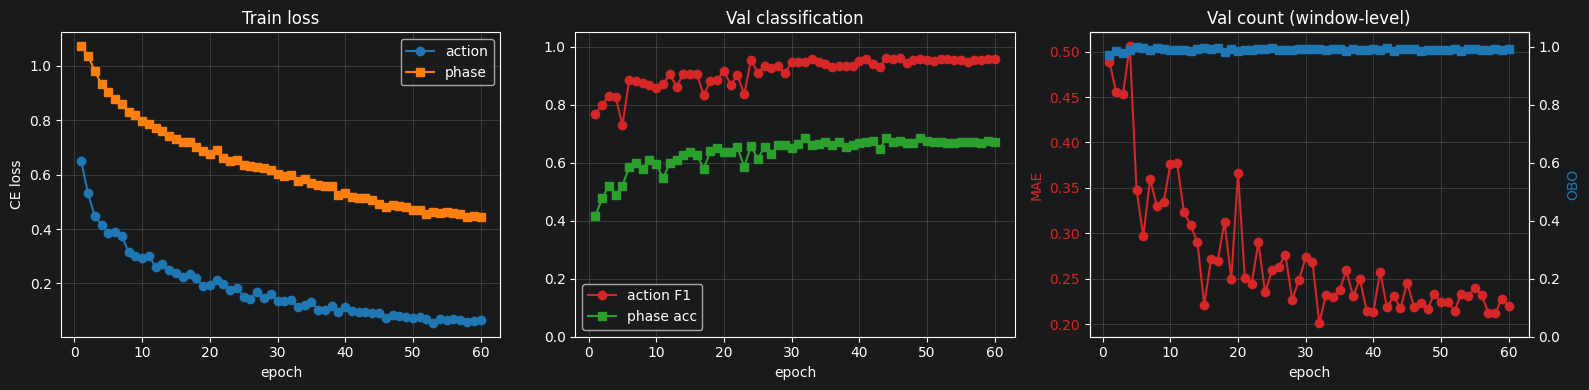

In [18]:
import matplotlib.pyplot as plt

if (WORK_DIR / 'history_v5.json').exists():
    with open(WORK_DIR / 'history_v5.json') as f:
        history = json.load(f)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    ep = np.arange(1, len(history['train_loss']) + 1)

    axes[0].plot(ep, history['train_ce_a'], 'o-', label='action', color='tab:blue')
    axes[0].plot(ep, history['train_ce_p'], 's-', label='phase',  color='tab:orange')
    axes[0].set_xlabel('epoch'); axes[0].set_ylabel('CE loss')
    axes[0].set_title('Train loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(ep, history['val_action_f1'], 'o-', color='tab:red',   label='action F1')
    axes[1].plot(ep, history['val_phase_acc'], 's-', color='tab:green', label='phase acc')
    axes[1].set_ylim(0, 1.05); axes[1].set_xlabel('epoch')
    axes[1].set_title('Val classification'); axes[1].legend(); axes[1].grid(alpha=0.3)

    ax = axes[2]
    ax.plot(ep, history['val_count_mae'], 'o-', color='tab:red', label='MAE')
    ax.set_ylabel('MAE', color='tab:red'); ax.tick_params(axis='y', labelcolor='tab:red')
    ax2 = ax.twinx()
    ax2.plot(ep, history['val_count_obo'], 's-', color='tab:blue', label='OBO')
    ax2.set_ylabel('OBO', color='tab:blue'); ax2.set_ylim(0, 1.05)
    ax.set_xlabel('epoch'); ax.set_title('Val count (window-level)')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(PLOT_DIR / 'v5_curves.png', dpi=100, bbox_inches='tight')
    plt.show()

## 15. Sliding Window 추론 (v4와 동일)

In [19]:
@torch.no_grad()
def predict_video_v5(video_path, ckpt_path=None, clip_len=CLIP_LEN,
                     step=None, smooth_window=5, min_up_len=3, model=None):
    if model is None:
        assert ckpt_path is not None
        model = MultiTaskSTGCN(target_T=clip_len).to(DEVICE)
        ckpt = torch.load(ckpt_path, map_location=DEVICE)
        model.load_state_dict(ckpt['model'])
        model.eval()

    tmp = WORK_DIR / 'tmp_v5_infer.npz'
    T, fps = extract_pose(video_path, tmp)
    k = normalize_kpts(np.load(tmp)['kpts'].astype(np.float32))

    if step is None:
        step = clip_len // 2

    action_votes = np.zeros(NUM_CLASSES)
    phase_logits_sum = np.zeros((NUM_PHASES, T), dtype=np.float32)
    phase_counts = np.zeros(T, dtype=np.float32) + 1e-6

    if T <= clip_len:
        clip = temporal_resample_kpts(k, clip_len)
        xb = torch.from_numpy(clip).permute(2, 0, 1).unsqueeze(-1).unsqueeze(0).to(DEVICE)
        a_logit, p_logit = model(xb)
        action_votes += F.softmax(a_logit[0], dim=0).cpu().numpy()
        p_np = p_logit[0].cpu().numpy()
        for c in range(NUM_PHASES):
            phase_logits_sum[c, :] = np.interp(np.linspace(0, 1, T),
                                                np.linspace(0, 1, clip_len),
                                                p_np[c])
        phase_counts[:] = 1.0
    else:
        positions = list(range(0, T - clip_len + 1, step))
        if positions[-1] != T - clip_len:
            positions.append(T - clip_len)
        for s in positions:
            clip = k[s:s+clip_len]
            xb = torch.from_numpy(clip).permute(2, 0, 1).unsqueeze(-1).unsqueeze(0).to(DEVICE)
            a_logit, p_logit = model(xb)
            action_votes += F.softmax(a_logit[0], dim=0).cpu().numpy()
            p_np = p_logit[0].cpu().numpy()
            for c in range(NUM_PHASES):
                phase_logits_sum[c, s:s+clip_len] += p_np[c]
            phase_counts[s:s+clip_len] += 1

    cls_id = int(action_votes.argmax())
    cls_name = ID_TO_CLASS[cls_id]
    phase_logits_avg = phase_logits_sum / phase_counts[None, :]
    phase_seq = phase_logits_avg.argmax(axis=0)

    phase_seq_smooth = smooth_phase(phase_seq, smooth_window)
    count, transitions = count_phases(phase_seq_smooth, min_up_len=min_up_len)

    return {
        'class': cls_name,
        'count': int(count),
        'phase_seq_raw': phase_seq,
        'phase_seq': phase_seq_smooth,
        'phase_prob': phase_logits_avg,
        'transitions': transitions,
        'T': T,
        'fps': fps,
        'action_probs': action_votes / action_votes.sum(),
    }

테스트 영상: squat_3.MOV


C:\Users\kojy1\anaconda3\envs\capstone\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


종목: squat  |  횟수: 5
정답: 5회 (오차 0)


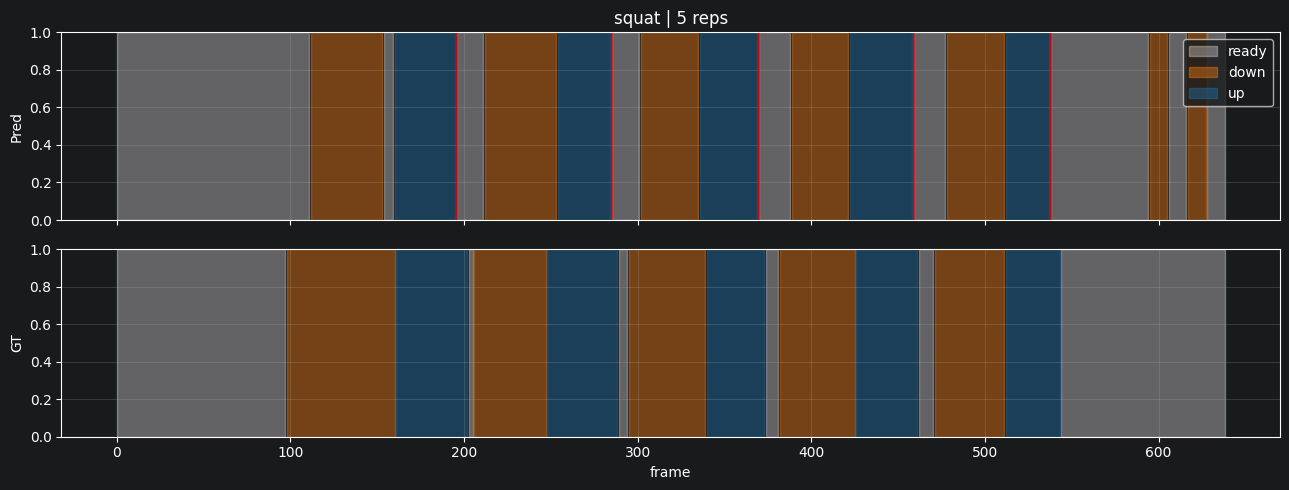

In [20]:
# 단일 영상 테스트
sample_path = None
for cand_typ in CLASS_LIST:
    sub = meta_df[(meta_df['type']==cand_typ) & (meta_df['split']=='val') & (meta_df['n_reps']>=3)]
    if len(sub) > 0:
        sample_path = VIDEO_DIR / sub.iloc[0]['type'] / sub.iloc[0]['name']
        break

if sample_path and sample_path.exists():
    print('테스트 영상:', sample_path.name)
    out = predict_video_v5(sample_path, ckpt_path=CKPT_V5)
    print(f"종목: {out['class']}  |  횟수: {out['count']}")
    gt_key = (sample_path.parent.name, sample_path.name)
    if gt_key in LABELS:
        gt_n = len(LABELS[gt_key]['reps'])
        print(f'정답: {gt_n}회 (오차 {abs(out["count"] - gt_n)})')

    fig, axes = plt.subplots(2, 1, figsize=(13, 5), sharex=True)
    T = out['T']; t_axis = np.arange(T)
    ax = axes[0]
    for c, (nm, color) in enumerate([('ready', 'lightgray'),
                                      ('down',  'tab:orange'),
                                      ('up',    'tab:blue')]):
        mask = out['phase_seq'] == c
        ax.fill_between(t_axis, 0, 1, where=mask, alpha=0.4, color=color, label=nm)
    for tr in out['transitions']:
        ax.axvline(tr, color='red', lw=1.5, alpha=0.7)
    ax.set_ylabel('Pred'); ax.set_ylim(0, 1)
    ax.set_title(f"{out['class']} | {out['count']} reps")
    ax.legend(loc='upper right'); ax.grid(alpha=0.3)

    if gt_key in LABELS:
        gt_phase = make_phase_target(T, LABELS[gt_key]['reps'])
        ax = axes[1]
        for c, (nm, color) in enumerate([('ready', 'lightgray'),
                                          ('down',  'tab:orange'),
                                          ('up',    'tab:blue')]):
            mask = gt_phase == c
            ax.fill_between(t_axis, 0, 1, where=mask, alpha=0.4, color=color)
        ax.set_ylabel('GT'); ax.set_ylim(0, 1)
        ax.set_xlabel('frame'); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

## 16. Val 전체 평가

In [ ]:
import time

model = MultiTaskSTGCN(target_T=CLIP_LEN).to(DEVICE)
ckpt = torch.load(CKPT_V5, map_location=DEVICE)
model.load_state_dict(ckpt['model'])
model.eval()

val_results = []
for _, r in tqdm(val_meta.iterrows(), total=len(val_meta)):
    p = VIDEO_DIR / r['type'] / r['name']
    if not p.exists(): continue
    t0 = time.time()
    try:
        out = predict_video_v5(p, model=model)
    except Exception as e:
        print('FAIL:', r['name'], e); continue
    elapsed = time.time() - t0
    gt_n = len(LABELS[(r['type'], r['name'])]['reps'])
    val_results.append({
        'type': r['type'], 'name': r['name'],
        'gt_cls': r['type'], 'pred_cls': out['class'],
        'gt_count': gt_n, 'pred_count': out['count'],
        'diff': abs(out['count'] - gt_n),
        'T': out['T'], 'fps': out['fps'], 'elapsed': elapsed,
    })

vr = pd.DataFrame(val_results)
action_acc = (vr['gt_cls'] == vr['pred_cls']).mean()
mae = vr['diff'].mean()
obo = (vr['diff'] <= 1).mean()
rt_factor = (vr['elapsed'] / (vr['T'] / vr['fps'])).mean()

print('=== v5 Val 전체 (영상 단위) ===')
print(f'Action accuracy: {action_acc:.3f}')
print(f'Count MAE      : {mae:.2f}')
print(f'Count OBO      : {obo:.2f}')
print(f'rt_factor      : {rt_factor:.3f}x')

print()
print('=== 종목별 ===')
g = vr.groupby('type').agg(
    n=('name', 'count'),
    cnt_mae=('diff', 'mean'),
    cnt_obo=('diff', lambda s: (s <= 1).mean()),
).round(3)
print(g.to_string())

## 17. GUI (v4와 동일)

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

all_videos = []
for typ in CLASS_LIST:
    for f in sorted((VIDEO_DIR / typ).glob('*.mp4')):
        is_val = ((meta_df['type']==typ) & (meta_df['name']==f.name) &
                  (meta_df['split']=='val')).any()
        tag = '[VAL]' if is_val else '     '
        all_videos.append((f'{tag} {typ}/{f.name}', str(f)))

test_folder = VIDEO_DIR / 'test'
if test_folder.exists():
    for f in sorted(test_folder.glob('*.mp4')):
        all_videos.append((f'[TEST] test/{f.name}', str(f)))

video_dd = widgets.Dropdown(options=all_videos, description='영상:',
                            layout=widgets.Layout(width='600px'))
smooth_slider = widgets.IntSlider(value=5, min=1, max=21, step=2,
                                   description='smooth', continuous_update=False)
min_up_slider = widgets.IntSlider(value=3, min=1, max=20,
                                   description='min_up_len', continuous_update=False)
run_btn = widgets.Button(description='Run', button_style='primary')
out_area = widgets.Output()

_cache = {'path': None, 'result': None}

def run_inference(b=None):
    with out_area:
        clear_output(wait=True)
        path = Path(video_dd.value)
        if _cache['path'] != str(path):
            print(f'추론 중: {path.name} ...')
            res = predict_video_v5(path, model=model,
                                    smooth_window=smooth_slider.value,
                                    min_up_len=min_up_slider.value)
            _cache.update(path=str(path), result=res)
        else:
            raw_seq = _cache['result']['phase_seq_raw']
            smoothed = smooth_phase(raw_seq, smooth_slider.value)
            cnt, trs = count_phases(smoothed, min_up_len=min_up_slider.value)
            res = dict(_cache['result'])
            res['phase_seq'] = smoothed
            res['count'] = cnt
            res['transitions'] = trs

        cls_name = res['class']; T = res['T']; fps = res['fps']
        gt = LABELS.get((path.parent.name, path.name))
        gt_cls = path.parent.name if gt else '?'
        gt_n = len(gt['reps']) if gt else None

        print('=' * 60)
        cls_ok = 'OK' if cls_name == gt_cls else 'MISS'
        print(f'  종목: {cls_name:12s} | 정답: {gt_cls}  [{cls_ok}]')
        if gt_n is not None:
            diff = abs(res['count'] - gt_n)
            cnt_ok = 'OK' if diff <= 1 else 'MISS'
            print(f"  횟수: {res['count']:3d} | 정답: {gt_n} [{cnt_ok}, diff={diff}]")
        else:
            print(f"  횟수: {res['count']}")
        print(f'  영상: {T} frames @ {fps:.0f}fps ({T/fps:.1f}s)')
        print('=' * 60)

        n_rows = 2 if gt else 1
        fig, axes = plt.subplots(n_rows, 1, figsize=(13, 3*n_rows), sharex=True)
        if n_rows == 1: axes = [axes]
        t_axis = np.arange(T)
        ax = axes[0]
        for c, (nm, color) in enumerate([('ready', 'lightgray'),
                                          ('down',  'tab:orange'),
                                          ('up',    'tab:blue')]):
            mask = res['phase_seq'] == c
            ax.fill_between(t_axis, 0, 1, where=mask, alpha=0.4, color=color, label=nm)
        for tr in res['transitions']:
            ax.axvline(tr, color='red', lw=1.5, alpha=0.7)
        ax.set_ylabel('Pred'); ax.set_ylim(0, 1)
        ax.set_title(f"{cls_name} | {res['count']} reps")
        ax.legend(loc='upper right', fontsize=8); ax.grid(alpha=0.3)

        if gt:
            ax = axes[1]
            gt_phase = make_phase_target(T, gt['reps'])
            for c, (nm, color) in enumerate([('ready', 'lightgray'),
                                              ('down',  'tab:orange'),
                                              ('up',    'tab:blue')]):
                mask = gt_phase == c
                ax.fill_between(t_axis, 0, 1, where=mask, alpha=0.4, color=color)
            ax.set_ylabel('GT'); ax.set_ylim(0, 1)
            ax.set_xlabel('frame'); ax.grid(alpha=0.3)
        plt.tight_layout(); plt.show()

for w in [smooth_slider, min_up_slider]:
    w.observe(lambda c: run_inference(), names='value')
run_btn.on_click(run_inference)

display(widgets.VBox([
    widgets.HBox([video_dd, run_btn]),
    widgets.HBox([smooth_slider, min_up_slider]),
]), out_area)

## 끝

### 산출물
- `workdir/checkpoints/multitask_v5_best.pt`
- `workdir/history_v5.json`

### v4 대비 변경 요약
| 항목 | v4 | v5 |
|---|---|---|
| 학습 샘플 | 영상 1개당 random crop 1개 (156개) | 영상마다 모든 윈도우 enumerate (~1,500~2,500개) |
| Dataset 길이 | 156 | ~1,500~2,500 |
| Batch size | 16 | 32 |
| Synth prob | 0.5 | 0.3 (실제 데이터 충분해짐) |
| Stride | - | 48 (clip_len의 50%) |
| 윈도우 위치 jitter | - | ±stride/4 (train만) |
| 영상별 max windows | - | 20 (긴 영상 비대칭 완화) |

학습 시간은 epoch당 약 10배 증가 (윈도우 수 10배). 60 epoch 기준 약 5~6시간 예상.


In [22]:
# ============================================================
# Ablation Experiment Cell
# ※ 위 셀들이 모두 실행된 상태에서 실행하세요
# ============================================================

import itertools, json, time
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error

# ── 실험 그리드 ───────────────────────────────────────────────
ABLATION_GRID = {
    'lstm_hidden' : [64, 128],
    'lstm_layers' : [1, 2],
    'clip_len'    : [16,32, 96],
    'train_stride': [1, 2,4],
    'dropout'     : [0.1, 0.3],
    'aug'         : [True, False],
}

# 직접 지정하려면 여기에 list로, None이면 그리드 전체
ABLATION_CONFIGS = None

# ── 고정 설정 (기존 노트북 상수 참고) ────────────────────────
FIXED = dict(
    epochs           = EPOCHS,               # 기존 셀 변수 재사용
    batch            = BATCH,
    lr               = LR,
    weight_decay     = 1e-4,
    phase_loss_alpha = PHASE_LOSS_ALPHA,
    val_stride       = VAL_STRIDE,
    smooth_window    = 5,
    min_up_len       = 3,
    num_workers      = 0,
)

# ── 저장 경로 ─────────────────────────────────────────────────
ABLATION_ROOT    = WORK_DIR / 'ablation'
ABLATION_ROOT.mkdir(parents=True, exist_ok=True)
ABLATION_LOG_CSV  = ABLATION_ROOT / 'ablation_results.csv'
ABLATION_LOG_JSON = ABLATION_ROOT / 'ablation_results.json'


# ── 실험 이름 ─────────────────────────────────────────────────
def make_exp_name(cfg):
    return (
        f"h{cfg['lstm_hidden']}"
        f"_l{cfg['lstm_layers']}"
        f"_c{cfg['clip_len']}"
        f"_ts{cfg['train_stride']}"
        f"_do{str(cfg['dropout']).replace('.','')}"
        f"_aug{int(cfg['aug'])}"
    )


# ── class/phase weight 계산 ───────────────────────────────────
def compute_weights_from_ds(ds):
    cls_c   = np.zeros(NUM_CLASSES, dtype=np.float64)
    phase_c = np.zeros(NUM_PHASES,  dtype=np.float64)
    for s in ds.samples:
        cls_c[int(s['cls'])]     += 1
        phase_c[int(s['phase'])] += 1
    cls_w   = cls_c.sum() / (NUM_CLASSES * np.maximum(cls_c, 1))
    phase_w = 1.0 / (phase_c / max(phase_c.sum(), 1) + 1e-6)
    phase_w = phase_w / phase_w.mean()
    return (
        torch.tensor(cls_w,   dtype=torch.float32, device=DEVICE),
        torch.tensor(phase_w, dtype=torch.float32, device=DEVICE),
    )


# ── 윈도우 단위 검증 ──────────────────────────────────────────
@torch.no_grad()
def ablation_eval_windows(model, dl, cw, pw):
    model.eval()
    a_preds, a_gts, p_preds, p_gts, losses = [], [], [], [], []
    for x, y_cls, y_phase in dl:
        x, y_cls, y_phase = x.to(DEVICE), y_cls.to(DEVICE), y_phase.to(DEVICE)
        a_logit, p_logit  = model(x)
        loss, _, _ = multitask_loss(
            a_logit, p_logit, y_cls, y_phase,
            alpha=FIXED['phase_loss_alpha'], class_weight=cw, phase_weight=pw,
        )
        losses.append(float(loss.item()))
        a_preds.extend(a_logit.argmax(1).cpu().tolist())
        a_gts.extend(y_cls.cpu().tolist())
        p_preds.extend(p_logit.argmax(1).cpu().tolist())
        p_gts.extend(y_phase.cpu().tolist())
    return {
        'val_loss'  : float(np.mean(losses)),
        'action_f1' : f1_score(a_gts, a_preds, average='macro', zero_division=0),
        'phase_f1'  : f1_score(p_gts, p_preds, average='macro', zero_division=0),
    }


# ── 영상 단위 최종 평가 ───────────────────────────────────────
def ablation_eval_videos(model, val_meta, clip_len):
    rows = []
    all_gt, all_pred = [], []
    for _, r in val_meta.iterrows():
        kpts = np.load(r['npz'])['kpts'].astype(np.float32)
        T    = min(int(r['T']), len(kpts))
        out  = predict_from_kpts(
            model, kpts[:T],
            clip_len=clip_len,
            stride=FIXED['val_stride'],
            smooth_window=FIXED['smooth_window'],
            min_up_len=FIXED['min_up_len'],
        )
        gt_key   = (r['type'], r['name'])
        gt_count = len(LABELS[gt_key]['reps'])
        gt_phase = make_phase_target(T, LABELS[gt_key]['reps'])
        valid    = np.arange(T) >= (clip_len - 1 if T >= clip_len else T - 1)
        all_gt.extend(gt_phase[valid].tolist())
        all_pred.extend(out['phase_smooth'][valid].tolist())
        rows.append({
            'gt_cls'    : r['type'],
            'pred_cls'  : out['pred_class'],
            'gt_count'  : gt_count,
            'pred_count': out['pred_count'],
            'abs_error' : abs(out['pred_count'] - gt_count),
        })
    vr = pd.DataFrame(rows)
    return {
        'video_action_f1' : f1_score(vr['gt_cls'], vr['pred_cls'], average='macro', zero_division=0),
        'video_phase_f1'  : f1_score(all_gt, all_pred, average='macro', zero_division=0),
        'video_count_mae' : mean_absolute_error(vr['gt_count'], vr['pred_count']),
        'video_count_obo' : float((vr['abs_error'] <= 1).mean()),
    }


# ── 단일 실험 ─────────────────────────────────────────────────
def run_one_experiment(cfg, train_meta, val_meta):
    exp_name   = make_exp_name(cfg)
    exp_dir    = ABLATION_ROOT / exp_name
    exp_dir.mkdir(parents=True, exist_ok=True)
    best_path  = exp_dir / 'best.pt'
    latest_path= exp_dir / 'latest.pt'
    hist_path  = exp_dir / 'history.json'

    print(f'\n{"="*60}')
    print(f'[EXP] {exp_name}')

    # 완료 스킵
    if best_path.exists() and hist_path.exists():
        print('  → 완료된 실험, best.pt로 평가만 진행')
        model = MultiTaskSTGCNLSTM(
            num_action=NUM_CLASSES, num_phase=NUM_PHASES, in_c=3,
            lstm_hidden=cfg['lstm_hidden'], lstm_layers=cfg['lstm_layers'],
            dropout=cfg['dropout'],
        ).to(DEVICE)
        ckpt = torch.load(best_path, map_location=DEVICE)
        model.load_state_dict(ckpt['model'])
        model.eval()
        vm = ablation_eval_videos(model, val_meta, cfg['clip_len'])
        return {'exp_name': exp_name, **cfg,
                'best_val_score': ckpt.get('best_score', float('nan')),
                'elapsed_min': 0, 'skipped': True, **vm}

    # Dataset
    train_ds = CausalWindowDataset(
        train_meta, clip_len=cfg['clip_len'], stride=cfg['train_stride'],
        train=True, aug=cfg['aug'],
    )
    val_ds = CausalWindowDataset(
        val_meta, clip_len=cfg['clip_len'], stride=FIXED['val_stride'],
        train=False, aug=False,
    )
    train_dl = DataLoader(train_ds, batch_size=FIXED['batch'], shuffle=True,
                          num_workers=FIXED['num_workers'], drop_last=True, pin_memory=True)
    val_dl   = DataLoader(val_ds,   batch_size=FIXED['batch'], shuffle=False,
                          num_workers=FIXED['num_workers'], pin_memory=True)
    print(f'  train={len(train_ds)} windows | val={len(val_ds)} windows')

    cw, pw = compute_weights_from_ds(train_ds)

    # 모델
    model = MultiTaskSTGCNLSTM(
        num_action=NUM_CLASSES, num_phase=NUM_PHASES, in_c=3,
        lstm_hidden=cfg['lstm_hidden'], lstm_layers=cfg['lstm_layers'],
        dropout=cfg['dropout'],
    ).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=FIXED['lr'], weight_decay=FIXED['weight_decay'])
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=FIXED['epochs'])

    history     = {'train_loss':[], 'val_action_f1':[], 'val_phase_f1':[]}
    best_score  = -1e9
    start_epoch = 1

    # 이어서 학습
    if latest_path.exists():
        ck = torch.load(latest_path, map_location=DEVICE)
        model.load_state_dict(ck['model'])
        opt.load_state_dict(ck['optimizer'])
        sched.load_state_dict(ck['scheduler'])
        start_epoch = int(ck.get('epoch', 0)) + 1
        best_score  = ck.get('best_score', -1e9)
        history     = ck.get('history', history)
        print(f'  → resume from epoch {start_epoch}')

    t0 = time.time()

    for ep in range(start_epoch, FIXED['epochs'] + 1):
        model.train()
        losses = []
        for x, y_cls, y_phase in train_dl:
            x, y_cls, y_phase = x.to(DEVICE), y_cls.to(DEVICE), y_phase.to(DEVICE)
            a_logit, p_logit  = model(x)
            loss, _, _ = multitask_loss(
                a_logit, p_logit, y_cls, y_phase,
                alpha=FIXED['phase_loss_alpha'], class_weight=cw, phase_weight=pw,
            )
            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
            losses.append(float(loss.item()))
        sched.step()

        vm = ablation_eval_windows(model, val_dl, cw, pw)
        score = vm['action_f1'] + vm['phase_f1']

        history['train_loss'].append(float(np.mean(losses)))
        history['val_action_f1'].append(vm['action_f1'])
        history['val_phase_f1'].append(vm['phase_f1'])

        print(f"  [ep {ep:02d}/{FIXED['epochs']}] "
              f"loss={np.mean(losses):.3f} | "
              f"a_f1={vm['action_f1']:.3f} p_f1={vm['phase_f1']:.3f} score={score:.3f}")

        # best 저장
        if score > best_score:
            best_score = score
            torch.save({'model': model.state_dict(), 'cfg': cfg,
                        'epoch': ep, 'best_score': float(best_score),
                        'clip_len': cfg['clip_len'],
                        'classes': CLASS_LIST, 'phase_names': PHASE_NAMES}, best_path)

        # latest 저장 (resume용)
        torch.save({'model': model.state_dict(), 'optimizer': opt.state_dict(),
                    'scheduler': sched.state_dict(), 'history': history,
                    'cfg': cfg, 'epoch': ep, 'best_score': float(best_score)}, latest_path)

        with open(hist_path, 'w') as f:
            json.dump(history, f, indent=2)

    elapsed = time.time() - t0
    print(f'  → 완료 | best_score={best_score:.4f} | {elapsed/60:.1f}min')

    # 영상 단위 평가 (best 모델로)
    ck = torch.load(best_path, map_location=DEVICE)
    model.load_state_dict(ck['model'])
    model.eval()
    video_m = ablation_eval_videos(model, val_meta, cfg['clip_len'])

    return {'exp_name': exp_name, **cfg,
            'best_val_score': float(best_score),
            'elapsed_min': round(elapsed / 60, 1),
            'skipped': False, **video_m}


# ── 실험 목록 생성 ────────────────────────────────────────────
if ABLATION_CONFIGS is None:
    keys   = list(ABLATION_GRID.keys())
    ABLATION_CONFIGS = [
        dict(zip(keys, v))
        for v in itertools.product(*ABLATION_GRID.values())
    ]

print(f'총 실험 수: {len(ABLATION_CONFIGS)}개')

# 기존 결과 로드
all_results = []
if ABLATION_LOG_JSON.exists():
    with open(ABLATION_LOG_JSON) as f:
        all_results = json.load(f)
    print(f'기존 결과 {len(all_results)}개 로드')

done_names = {r['exp_name'] for r in all_results}

# ── 전체 실험 실행 ────────────────────────────────────────────
for i, cfg in enumerate(ABLATION_CONFIGS):
    exp_name = make_exp_name(cfg)

    if exp_name in done_names and (ABLATION_ROOT / exp_name / 'best.pt').exists():
        print(f'[{i+1}/{len(ABLATION_CONFIGS)}] {exp_name} → 스킵')
        continue

    result = run_one_experiment(cfg, train_meta, val_meta)
    all_results.append(result)
    done_names.add(exp_name)

    # 실험마다 즉시 저장
    with open(ABLATION_LOG_JSON, 'w') as f:
        json.dump(all_results, f, indent=2, ensure_ascii=False)
    pd.DataFrame(all_results).to_csv(ABLATION_LOG_CSV, index=False, encoding='utf-8-sig')

# ── 결과 요약 ─────────────────────────────────────────────────
results_df = pd.DataFrame(all_results).sort_values('video_count_obo', ascending=False).reset_index(drop=True)

print('\n' + '='*70)
print('Ablation 결과 (video_count_obo 기준 정렬)')
print('='*70)

show = ['exp_name', 'lstm_hidden', 'lstm_layers', 'clip_len', 'train_stride',
        'dropout', 'aug', 'best_val_score',
        'video_action_f1', 'video_phase_f1', 'video_count_mae', 'video_count_obo', 'elapsed_min']
print(results_df[[c for c in show if c in results_df.columns]].to_string())
print(f'\n저장: {ABLATION_LOG_CSV}')

device: cuda | torch: 2.11.0+cu128 | numpy: 2.4.4
ablation root: ..\data\측면\data\workdir\ablation
총 실험 수: 64개
  [01] h64_l1_c48_ts1_do01_aug1
  [02] h64_l1_c48_ts1_do01_aug0
  [03] h64_l1_c48_ts1_do03_aug1
  [04] h64_l1_c48_ts1_do03_aug0
  [05] h64_l1_c48_ts2_do01_aug1
  [06] h64_l1_c48_ts2_do01_aug0
  [07] h64_l1_c48_ts2_do03_aug1
  [08] h64_l1_c48_ts2_do03_aug0
  [09] h64_l1_c96_ts1_do01_aug1
  [10] h64_l1_c96_ts1_do01_aug0
  [11] h64_l1_c96_ts1_do03_aug1
  [12] h64_l1_c96_ts1_do03_aug0
  [13] h64_l1_c96_ts2_do01_aug1
  [14] h64_l1_c96_ts2_do01_aug0
  [15] h64_l1_c96_ts2_do03_aug1
  [16] h64_l1_c96_ts2_do03_aug0
  [17] h64_l2_c48_ts1_do01_aug1
  [18] h64_l2_c48_ts1_do01_aug0
  [19] h64_l2_c48_ts1_do03_aug1
  [20] h64_l2_c48_ts1_do03_aug0
  [21] h64_l2_c48_ts2_do01_aug1
  [22] h64_l2_c48_ts2_do01_aug0
  [23] h64_l2_c48_ts2_do03_aug1
  [24] h64_l2_c48_ts2_do03_aug0
  [25] h64_l2_c96_ts1_do01_aug1
  [26] h64_l2_c96_ts1_do01_aug0
  [27] h64_l2_c96_ts1_do03_aug1
  [28] h64_l2_c96_ts1_do03

NameError: name 'CausalWindowDataset' is not defined